#                               SPRINT 1: DATA UNDERSTANDING & PREPROCESSING

# Step1: Data Collection and Loading

In [1]:
# loading required librabries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# NEO Dataset
- The Near Earth Objects (NEO) dataset provides tracking metrics for $90,836$ spatial bodies passing close to Earth's orbit. It includes identifiers, physical dimensions, relative velocities, and close-approach miss distances. Crucially, it tracks absolute magnitude—a logarithmic measure of intrinsic brightness used by astronomers to estimate an asteroid's scale.

In [2]:
# Loadind Dataset
df=pd.read_csv('neo.csv')

In [3]:
df

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


# Column Structure
## id
    - A unique identifier for each individual asteroid or object.
## name
    - The name given to the object by the International Astronomical Union (IAU) or its temporary designation.
## est_diameter_min
    - The minimum estimated diameter of the object (typically measured in kilometers).
## est_diameter_max
    - The maximum estimated diameter of the object (typically measured in kilometers).
## relative_velocity
    - The speed at which the object is moving relative to Earth (usually in km/h).
## miss_distance
    - The distance at which the object passes Earth at its closest approach (usually in km).
## orbiting_body
    - The planet or celestial body that the object is currently orbiting (in this dataset, primarily Earth).
## sentry_object
    - A boolean (True/False) indicating if the object is included in Sentry, an automated collision monitoring system that tracks potential Earth impacts.
## absolute_magnitude
    - A measure of the object's intrinsic luminosity or brightness (H). Smaller values indicate larger or more reflective objects
## hazardous
    - The target variable; a boolean indicating whether the object is classified as a "Potentially Hazardous Asteroid" based on its size and proximity.

# Step 2: basic Checks on Dataset

In [4]:
# top 5 rows
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [5]:
# last 5 rows
df.tail()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False
90835,54205447,(2021 TW7),0.039862,0.089133,27024.455553,5.977213e+07,Earth,False,24.12,False


In [6]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [7]:
# shape of the dataset
df.shape

(90836, 10)

In [8]:
# checking for null values
df.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


In [9]:
# checking unique values
df.nunique()

,0
id,27423
name,27423
est_diameter_min,1638
est_diameter_max,1638
relative_velocity,90828
miss_distance,90536
orbiting_body,1
sentry_object,1
absolute_magnitude,1638
hazardous,2


In [10]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

# Step 3: Data Cleaning

In [11]:
# No null values
# No duplicates
# Standardized Columns

In [12]:
# checking for correlation between numeric columns
df.corr(numeric_only=True)

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude,hazardous
id,1.000000,-0.148322,-0.148322,-0.059176,-0.056510,NaN,0.277258,-0.123443
est_diameter_min,-0.148322,1.000000,1.000000,0.221553,0.142241,NaN,-0.560188,0.183363
est_diameter_max,-0.148322,1.000000,1.000000,0.221553,0.142241,NaN,-0.560188,0.183363
relative_velocity,-0.059176,0.221553,0.221553,1.000000,0.327169,NaN,-0.353863,0.191185
miss_distance,-0.056510,0.142241,0.142241,0.327169,1.000000,NaN,-0.264168,0.042302
sentry_object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
absolute_magnitude,0.277258,-0.560188,-0.560188,-0.353863,-0.264168,NaN,1.000000,-0.365267
hazardous,-0.123443,0.183363,0.183363,0.191185,0.042302,NaN,-0.365267,1.000000


# Step 4: EDA

## Univariate Analysis

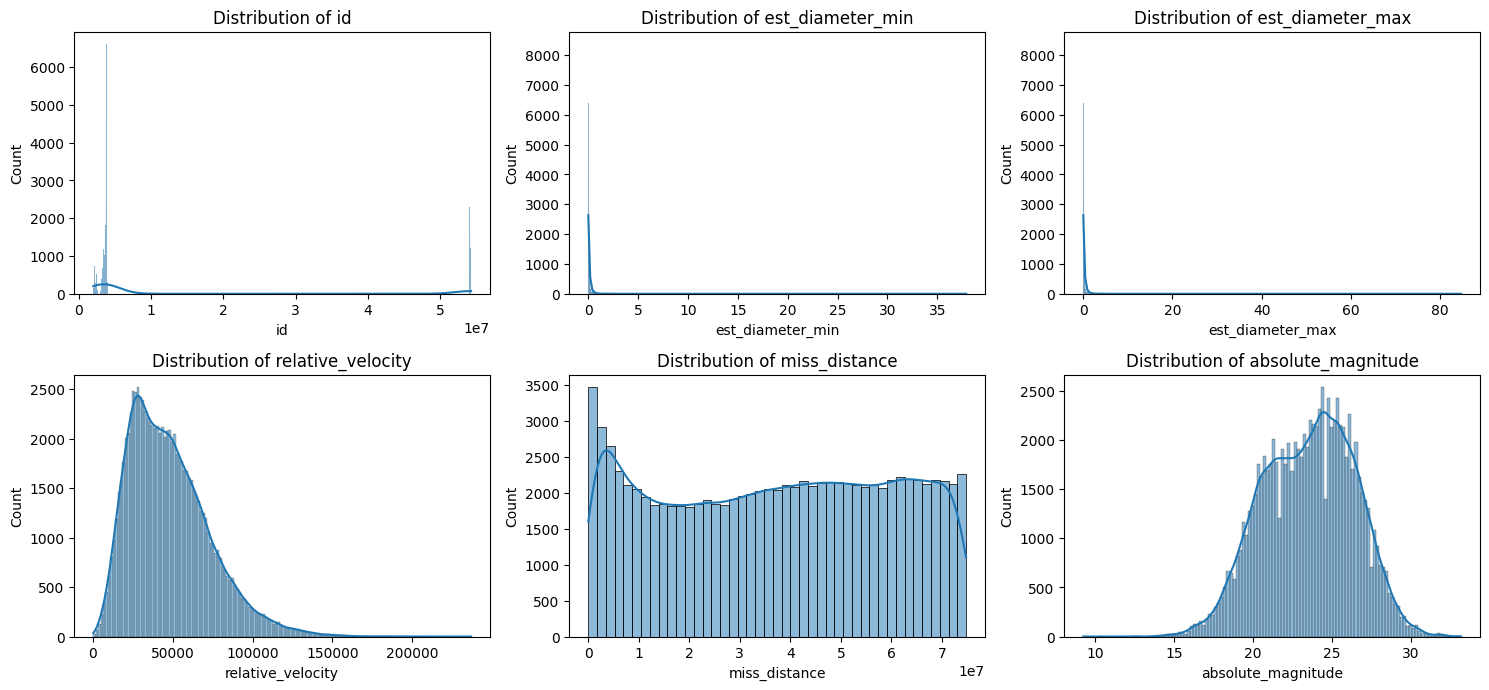

In [13]:
# univariate analysis
# Selecting numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plotting distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [14]:
# checking skewness
df.skew(numeric_only=True)

,0
id,1.378459
est_diameter_min,41.139952
est_diameter_max,41.139952
relative_velocity,0.905125
miss_distance,-0.042706
sentry_object,0.000000
absolute_magnitude,-0.137420
hazardous,2.717282


## Bivariate Analysis

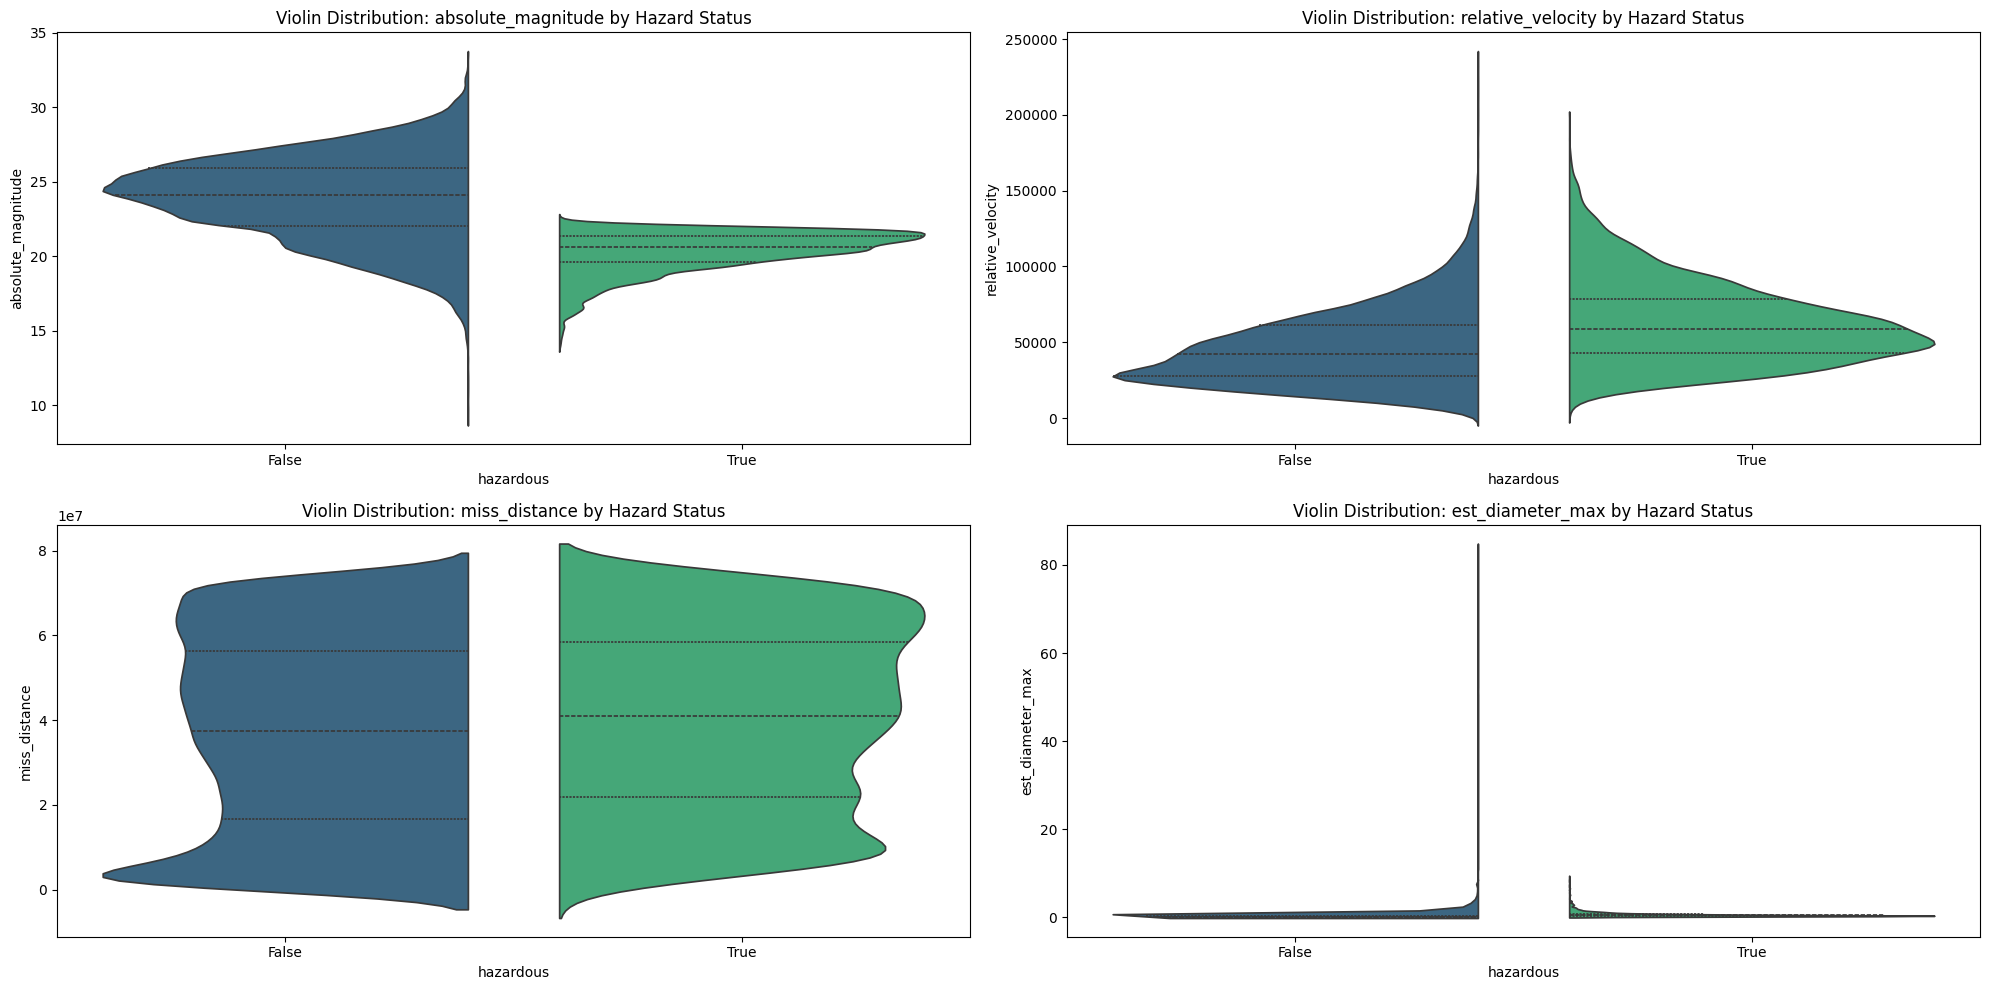

In [15]:
# Select key numerical features
num_features = ['absolute_magnitude', 'relative_velocity', 'miss_distance', 'est_diameter_max']

plt.figure(figsize=(20, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    # Using Violin plot as a non-boxplot alternative
    sns.violinplot(data=df, x='hazardous', y=col, hue='hazardous', palette='viridis', split=True, inner="quart", legend=False)
    plt.title(f'Violin Distribution: {col} by Hazard Status')

plt.tight_layout()
plt.show()

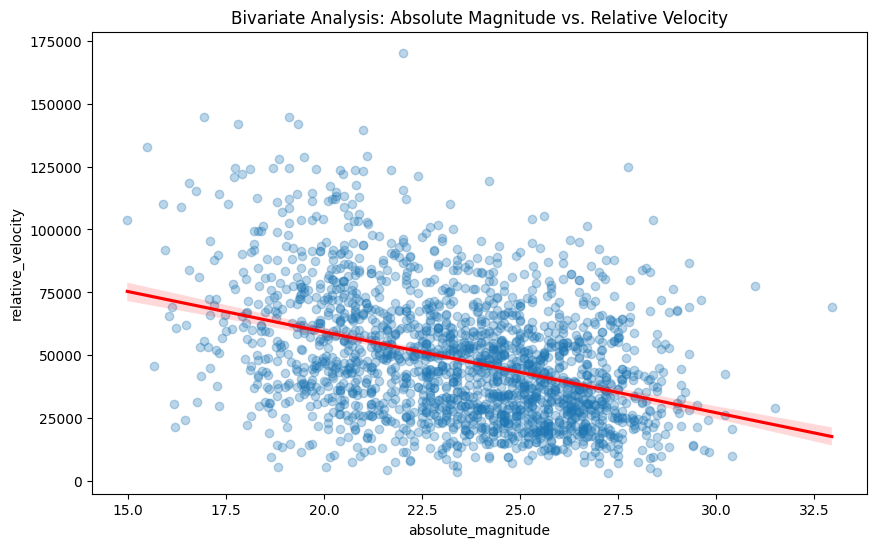

In [16]:
plt.figure(figsize=(10, 6))
# Checking the relationship between Magnitude and Velocity
sns.regplot(data=df.sample(2000), x='absolute_magnitude', y='relative_velocity',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Analysis: Absolute Magnitude vs. Relative Velocity')
plt.show()

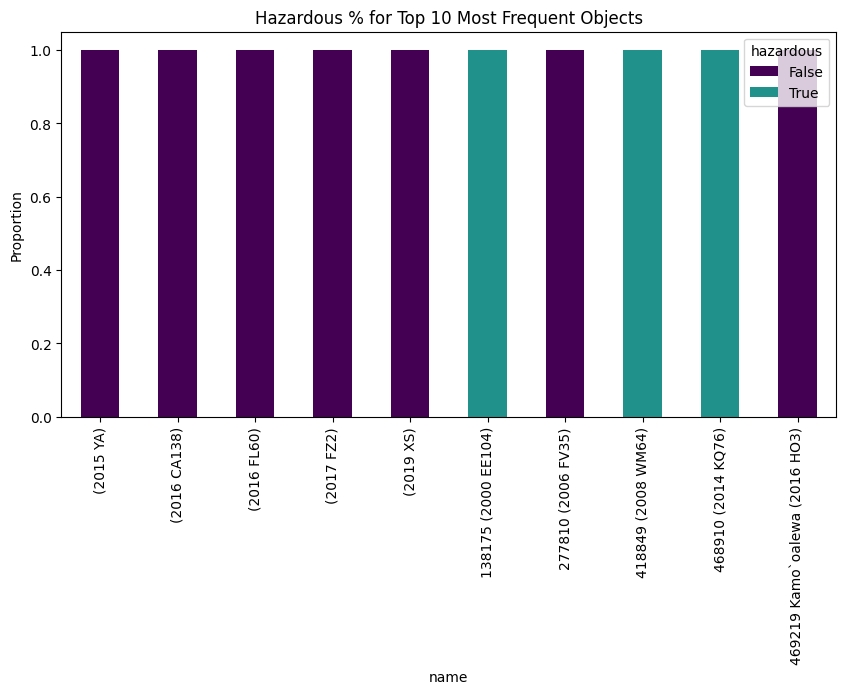

In [17]:
# Since name is high cardinality, let's look at the top 10 most frequent names
top_names = df['name'].value_counts().nlargest(10).index
df_top = df[df['name'].isin(top_names)]

# Crosstabulation (Percentage of hazardous per name)
ct = pd.crosstab(df_top['name'], df_top['hazardous'], normalize='index')
ct.plot(kind='bar', stacked=True, color=['#440154', '#21918c'], figsize=(10, 5))

plt.title('Hazardous % for Top 10 Most Frequent Objects')
plt.ylabel('Proportion')
plt.show()

## Correlation Analysis

In [18]:
# Selecting only numerical and boolean columns for analysis
# We exclude 'id' as it's a random identifier
corr_cols = df.select_dtypes(include=['float64', 'int64', 'bool']).columns
correlation_matrix = df[corr_cols].corr()

# Displaying the correlation values specifically for the Target
print("Correlation with Hazardous Status:")
print(correlation_matrix['hazardous'].sort_values(ascending=False))

Correlation with Hazardous Status:
hazardous             1.000000
relative_velocity     0.191185
est_diameter_max      0.183363
est_diameter_min      0.183363
miss_distance         0.042302
id                   -0.123443
absolute_magnitude   -0.365267
sentry_object              NaN
Name: hazardous, dtype: float64


## Multivariate Analysis

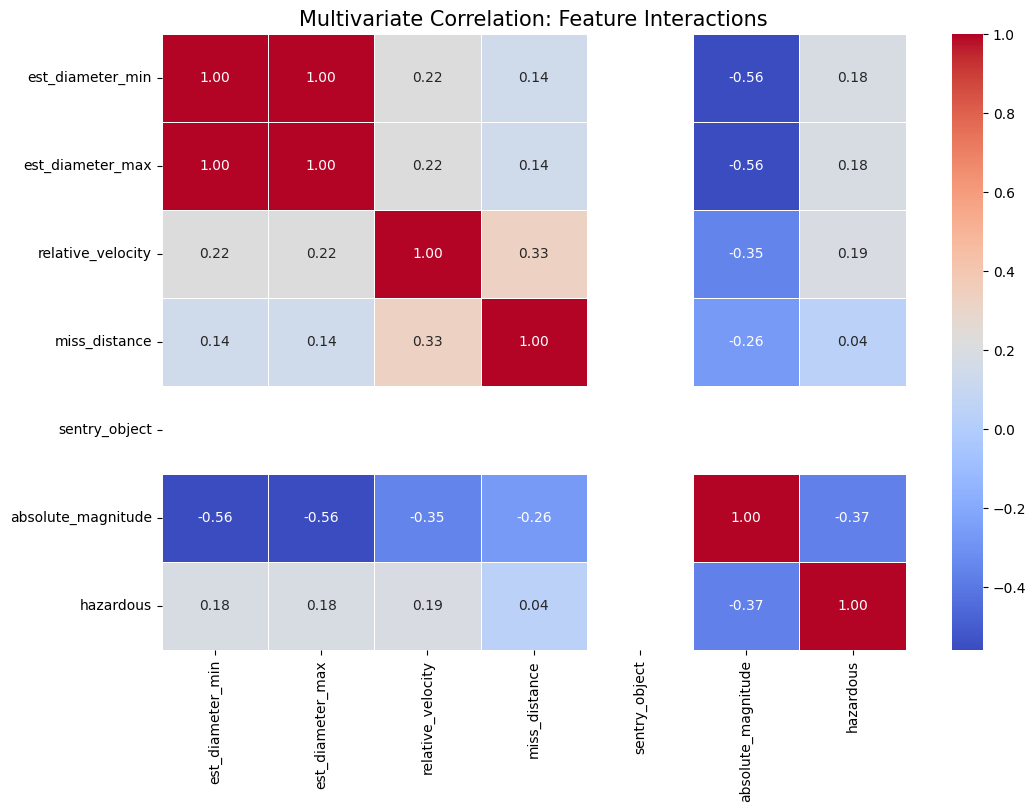

In [19]:
plt.figure(figsize=(12, 8))

# Select only numerical columns and the target
# We drop 'id' as it's not a physical attribute
multivariate_df = df.select_dtypes(include=['float64', 'int64', 'bool']).drop(columns=['id'], errors='ignore')

# Correlation matrix
corr = multivariate_df.corr()

# Plotting
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Multivariate Correlation: Feature Interactions', fontsize=15)
plt.show()

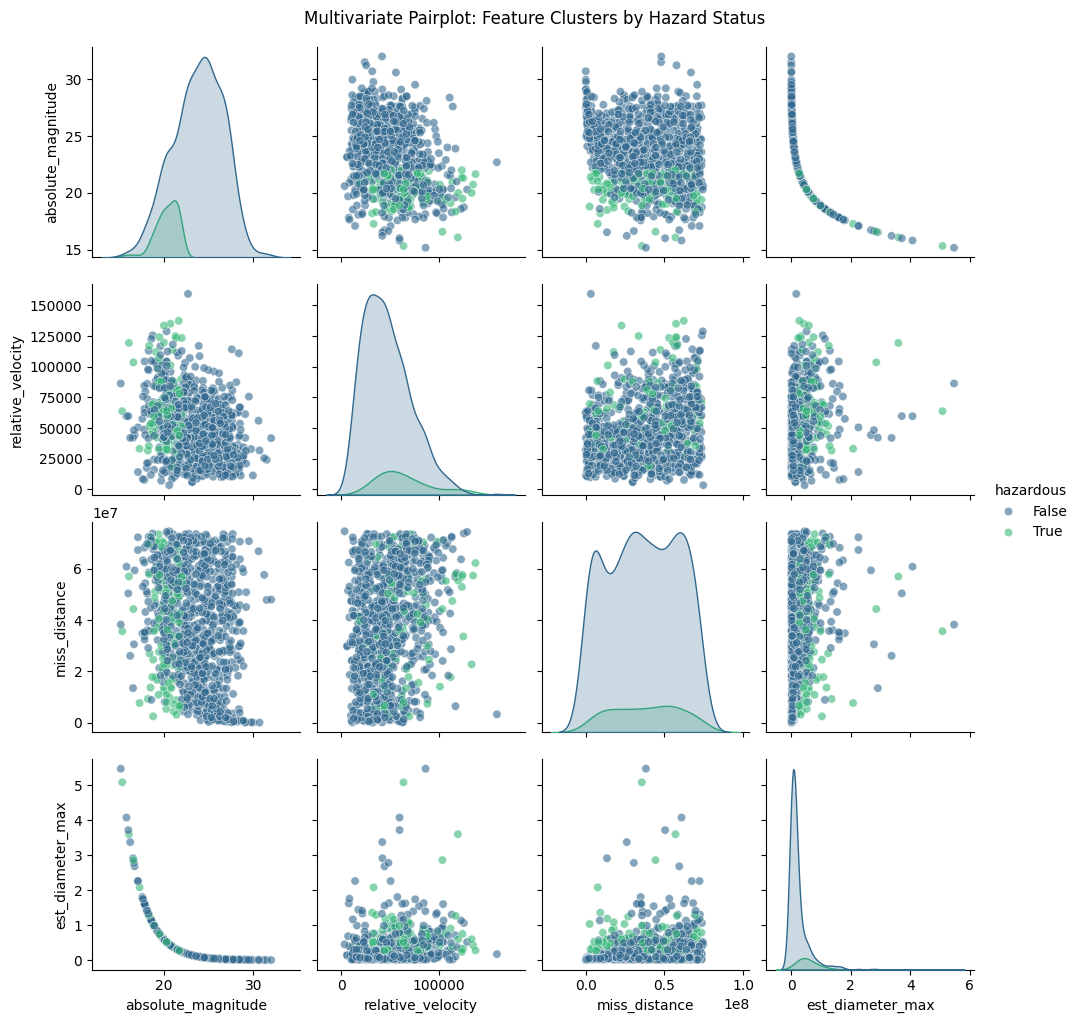

In [20]:
# Selecting key features to keep the plot readable
columns_to_analyze = ['absolute_magnitude', 'relative_velocity', 'miss_distance', 'est_diameter_max', 'hazardous']

# Sampling 1000 points for performance
sns.pairplot(df[columns_to_analyze].sample(1000),
             hue='hazardous',
             palette='viridis',
             diag_kind='kde',
             plot_kws={'alpha': 0.6})

plt.suptitle('Multivariate Pairplot: Feature Clusters by Hazard Status', y=1.02)
plt.show()

## Interaction Effect
    - The Total Interaction Effect: A "Hazardous" label represents a High-Energy Convergence.
    - It is a logical AND gate: Hazardous = (Low Magnitude) AND (High Velocity) AND (Low Miss Distance).If any one of these three variables falls into a "safe" range (e.g., the object is too small or too far), the interaction breaks, and the target defaults to False

## Goal
    - The ultimate goal of this project is to build a machine learning model that accurately classifies Near-Earth Objects (NEOs) as hazardous or non-hazardous.
    - Based on your EDA and interaction analysis, this goal can be broken down into two core objectives:
### Accurate Risk Prediction
    - The primary technical goal is to develop a classification system that can ingest raw physical data—like brightness and speed—and determine if an asteroid poses a threat. Because the dataset is imbalanced (mostly non-hazardous), a major sub-goal is to ensure the model doesn't overlook the few "hazardous" cases.
### Identifying the "Danger Signature"
    - You are trying to mathematically define the High-Energy Convergence. As analysis showed, the goal isn't just to look at one variable, but to find the "sweet spot" where
#### Size
    - Size is large enough to survive the atmosphere.
#### Velocity
    - Velocity is high enough to cause significant impact
#### Distance
    - Distance is close enough to intersect Earth’s orbit.

## Step 5: Outlier Detection & Treatment

In [21]:
# Select only numerical columns
num_df = df.select_dtypes(include=['float64', 'int64'])

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

# Define outliers
outliers = ((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).sum()

print("Outlier count per column:")
print(outliers[outliers > 0])

Outlier count per column:
id                    31779
est_diameter_min       8306
est_diameter_max       8306
relative_velocity      1574
absolute_magnitude      101
dtype: int64


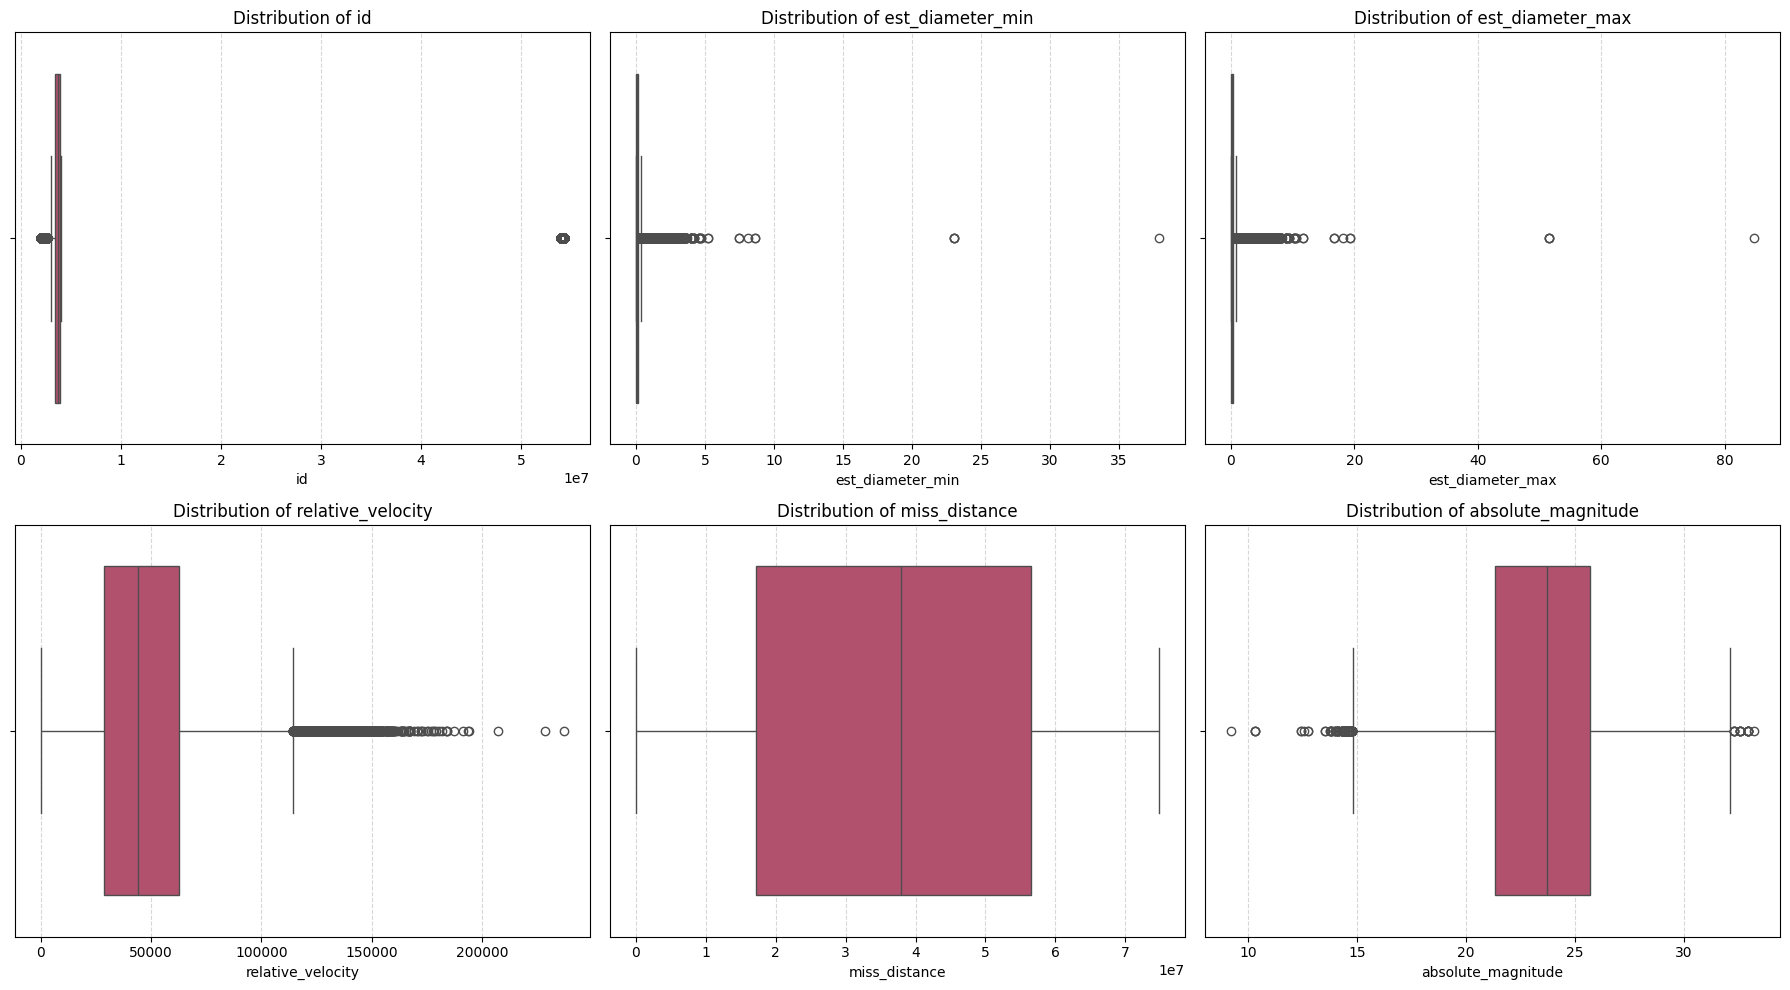

In [22]:

# 1. Filter only numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 2. Set up the grid dimensions
n_cols = 3  # Number of plots per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # Passing x=df[col] directly is faster than data=df
    sns.boxplot(x=df[col], palette='flare')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [23]:
# 1. Define columns to treat (excluding 'id' as it's just an identifier)
cols_to_fix = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

# 2. Apply Capping directly to df (No copy technique)
for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # This modifies the original df columns
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

# 3. Count outliers after treatment to verify
# We calculate IQR again on the modified data
num_df_after = df[cols_to_fix]
Q1_after = num_df_after.quantile(0.25)
Q3_after = num_df_after.quantile(0.75)
IQR_after = Q3_after - Q1_after

outliers_count = ((num_df_after < (Q1_after - 1.5 * IQR_after)) |
                  (num_df_after > (Q3_after + 1.5 * IQR_after))).sum()

print("Outlier count after treatment:")
print(outliers_count)

Outlier count after treatment:
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
dtype: int64


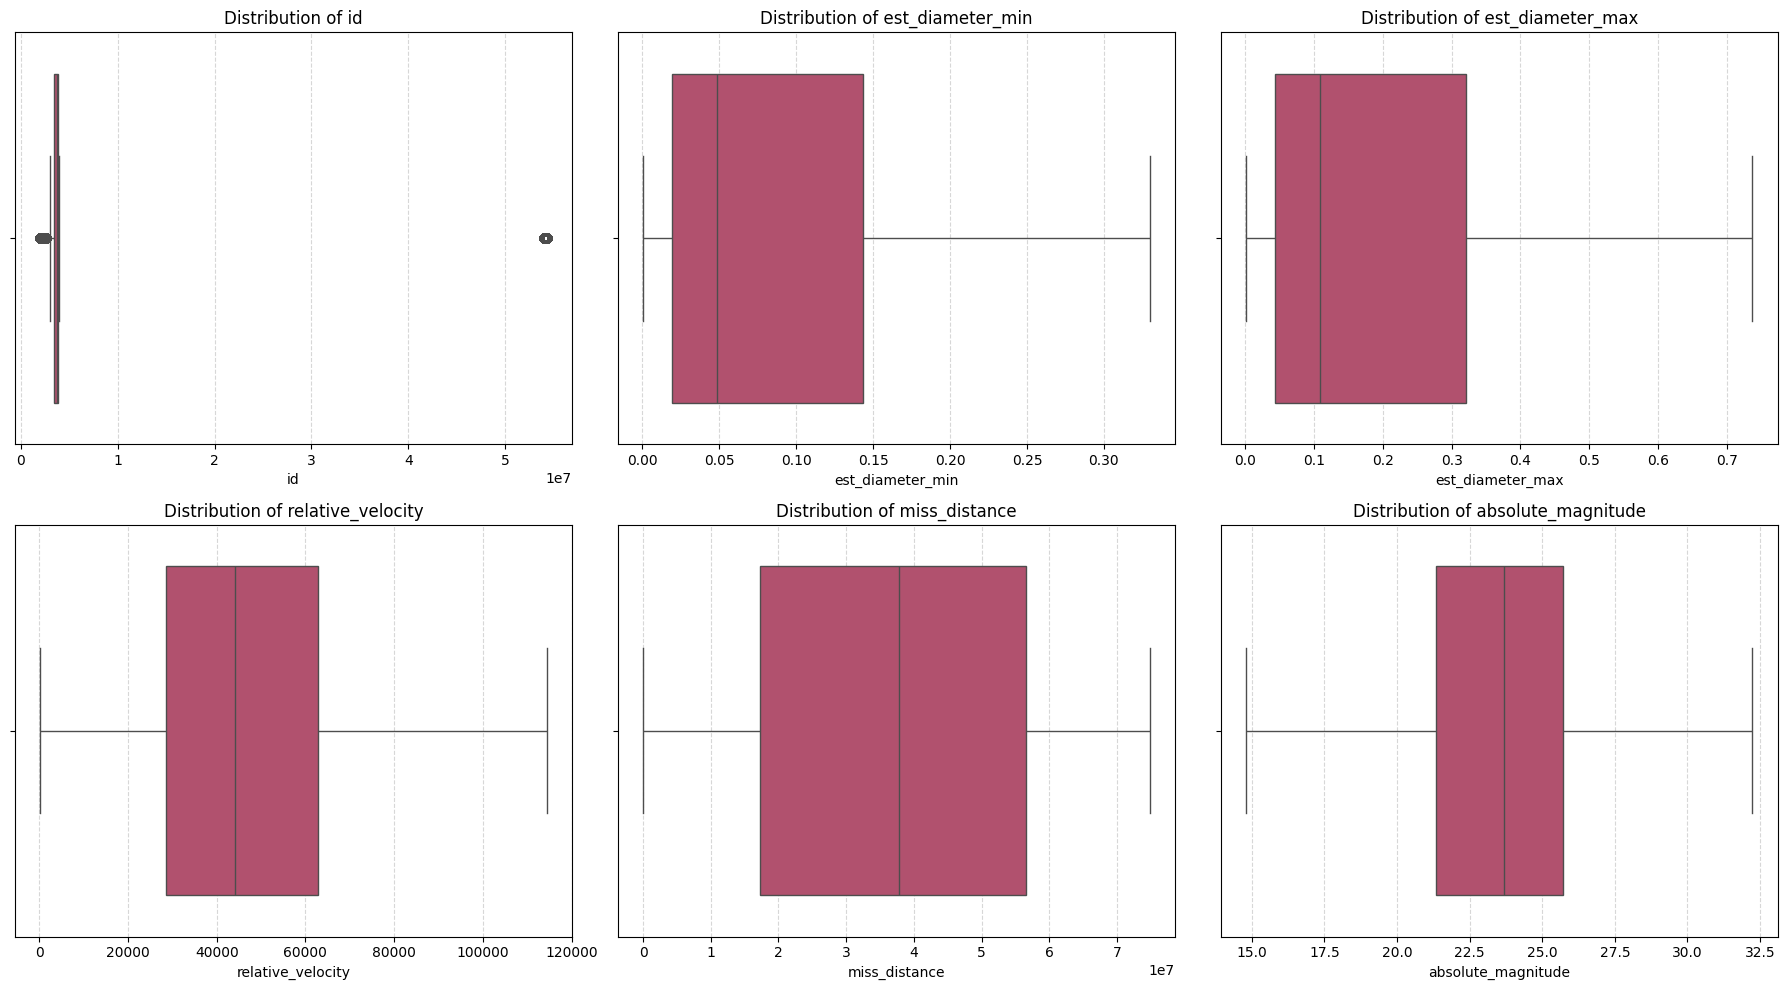

In [24]:
# 1. Filter only numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 2. Set up the grid dimensions
n_cols = 3  # Number of plots per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # Passing x=df[col] directly is faster than data=df
    sns.boxplot(x=df[col], palette='flare')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
df.skew(numeric_only=True)

,0
id,1.378459
est_diameter_min,1.211298
est_diameter_max,1.211298
relative_velocity,0.684025
miss_distance,-0.042706
sentry_object,0.000000
absolute_magnitude,-0.131136
hazardous,2.717282


# Step 6: Feature Encoding

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [27]:
df.nunique()

,0
id,27423
name,27423
est_diameter_min,1207
est_diameter_max,1207
relative_velocity,89255
miss_distance,90536
orbiting_body,1
sentry_object,1
absolute_magnitude,1610
hazardous,2


In [28]:
# As per correlation, the column "sentry_dody" does not show any dependence on target variable
df.drop(['id','name','sentry_object'], axis=1, inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   orbiting_body       90836 non-null  object 
 5   absolute_magnitude  90836 non-null  float64
 6   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(5), object(1)
memory usage: 4.2+ MB


In [30]:
y=df['hazardous']
x=df.drop('hazardous',axis=1)

In [31]:
print(x.shape)
print(y.shape)

(90836, 6)
(90836,)


In [32]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   orbiting_body       90836 non-null  object 
 5   absolute_magnitude  90836 non-null  float64
dtypes: float64(5), object(1)
memory usage: 4.2+ MB


In [33]:
# ColumnTransformer OrdinalEncoding and StandardScaler
ct=ColumnTransformer(transformers=[("oe",OrdinalEncoder(),[4]),
                                   ("sc",StandardScaler(),[0,1,2,3,5])])

In [34]:
x_tran=ct.fit_transform(x)

In [35]:
x_tran=pd.DataFrame(x_tran,columns=x.columns)

In [36]:
x_tran.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,absolute_magnitude
0,0.0,2.252657,2.252657,-1.399668,0.795153,-2.350838
1,0.0,1.635892,1.635892,1.053797,1.090357,-1.219975
2,0.0,2.252657,2.252657,2.716296,0.569624,-1.970425
3,0.0,-0.000145,-0.000145,-0.942039,-0.520384,-0.459151
4,0.0,1.531606,1.531606,-0.207325,0.412001,-1.188851


# Step 7: Feature Scaling

In [37]:
# feature scaling using mutual info classifier
mf=mutual_info_classif(x_tran,y)
mf=pd.Series(mf)
mf.index=x.columns
mf.sort_values(ascending=False)

,0
absolute_magnitude,0.142693
est_diameter_max,0.134612
relative_velocity,0.133515
miss_distance,0.021645
orbiting_body,0.006874
est_diameter_min,0.001047


In [38]:
x.drop(['est_diameter_min','orbiting_body','miss_distance'],axis=1, inplace= True)

# Step 8: Train_Test_Split

In [39]:
### we have split the data into train and test data x_train, X_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [40]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_max    90836 non-null  float64
 1   relative_velocity   90836 non-null  float64
 2   absolute_magnitude  90836 non-null  float64
dtypes: float64(3)
memory usage: 2.1 MB


In [41]:
ct=ColumnTransformer(transformers=[("sc",StandardScaler(),[0,1,2])])

In [42]:
x_train_tran=ct.fit_transform(x_train)
x_train_tran=pd.DataFrame(x_train_tran, columns=x_train.columns)

In [43]:
x_train_tran

,est_diameter_max,relative_velocity,absolute_magnitude
0,-0.561127,1.769519,0.231123
1,0.929663,-0.795131,-0.978983
2,-0.888046,2.433652,1.821547
3,-0.784787,-1.078642,0.922611
4,-0.820502,0.901032,1.130058
...,...,...,...
72663,1.109343,1.651238,-1.048131
72664,-0.593823,0.447419,0.300271
72665,1.109343,0.185699,-1.048131
72666,1.796693,0.110975,-1.265950


In [44]:
x_test_tran=ct.transform(x_test)
x_test_tran=pd.DataFrame(x_test_tran, columns=x_test.columns)

In [45]:
x_test_tran

,est_diameter_max,relative_velocity,absolute_magnitude
0,-0.698261,-1.048990,0.576867
1,-0.809675,-0.872074,1.060909
2,-0.803876,-0.573973,1.026335
3,0.938260,-0.172199,-0.982440
4,-0.506074,-0.466559,0.127399
...,...,...,...
18163,-0.847594,0.392477,1.337504
18164,-0.691693,0.125508,0.556122
18165,-0.851426,-0.934304,1.372079
18166,1.638085,0.394157,-1.221004


In [46]:
## in this step after the tain the model i got this output
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(72668, 3)
(18168, 3)
(72668,)
(18168,)


# Sprint 2 Model Building and Evaluation

In [47]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_max    90836 non-null  float64
 1   relative_velocity   90836 non-null  float64
 2   absolute_magnitude  90836 non-null  float64
dtypes: float64(3)
memory usage: 2.1 MB


In [48]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 90836 entries, 0 to 90835
Series name: hazardous
Non-Null Count  Dtype
--------------  -----
90836 non-null  bool 
dtypes: bool(1)
memory usage: 88.8 KB


# Step 1: Baseline Model

In [49]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the simple baseline model
print("Training Baseline Model (Logistic Regression)...")
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit exclusively on the scaled training data generated in Sprint 1
baseline_model.fit(x_train_tran, y_train)
print("Baseline model training complete.")

Training Baseline Model (Logistic Regression)...
Baseline model training complete.


# Step 2: Train Multiple Models

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Set up a dictionary containing multiple classification models
multiple_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', max_iter=5000, random_state=42)
}

# Train each model in a loop
for model_name, model_instance in multiple_models.items():
    print(f"Training {model_name}...")
    model_instance.fit(x_train_tran, y_train)

print("All alternative models trained successfully.")

Training Decision Tree...
Training Random Forest...
Training Naive Bayes...
Training Support Vector Machine (SVM)...
All alternative models trained successfully.


# Step 3: Model Evaluation

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a helper function to compile evaluation metrics
def calculate_metrics(true_labels, predicted_labels):
    return {
        "Accuracy": accuracy_score(true_labels, predicted_labels),
        "Precision": precision_score(true_labels, predicted_labels, zero_division=0),
        "Recall": recall_score(true_labels, predicted_labels),
        "F1-Score": f1_score(true_labels, predicted_labels)
    }

# Generate baseline predictions and evaluate
baseline_preds = baseline_model.predict(x_test_tran)
baseline_metrics = calculate_metrics(y_test, baseline_preds)
print("Baseline Model Metrics Calculated.")

Baseline Model Metrics Calculated.


# Step 4: Overfitting & Underfitting Check

In [52]:
# Check for Overfitting/Underfitting across all architectures
all_trained_models = {"Logistic Regression (Baseline)": baseline_model}
all_trained_models.update(multiple_models)

overfitting_evaluation = {}

for name, model in all_trained_models.items():
    train_preds = model.predict(x_train_tran)
    test_preds = model.predict(x_test_tran)

    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Flag overfitting if training accuracy vastly outperforms test accuracy
    gap = train_acc - test_acc
    is_overfitting = "Yes" if gap > 0.05 else "No"

    overfitting_evaluation[name] = {
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Overfitting?": is_overfitting,
        "Gap": round(gap, 4)
    }

print("Overfitting validation checks complete.")

Overfitting validation checks complete.


In [53]:
# Assemble the final model comparison table matrix
comparison_records = []

for name, model in all_trained_models.items():
    test_preds = model.predict(x_test_tran)
    metrics = calculate_metrics(y_test, test_preds)

    # Extract the matching overfitting status from Step 4
    overfit_status = overfitting_evaluation[name]["Overfitting?"]

    # Construct individual summary rows
    comparison_records.append({
        "Model": name,
        "Metric Score (F1)": round(metrics["F1-Score"], 4),
        "Accuracy": round(metrics["Accuracy"], 4),
        "Precision": round(metrics["Precision"], 4),
        "Recall": round(metrics["Recall"], 4),
        "Overfitting?": overfit_status,
        "Remarks": "Top baseline candidate" if name == "Random Forest" else "Standard baseline execution"
    })

# Convert to DataFrame to display the visual comparison sheet
df_comparison_table = pd.DataFrame(comparison_records)
print("\n--- Sprint 2: Model Comparison Table ---")
print(df_comparison_table)


--- Sprint 2: Model Comparison Table ---
                            Model  Metric Score (F1)  Accuracy  Precision  \
0  Logistic Regression (Baseline)             0.1047    0.8936     0.2628   
1                   Decision Tree             0.4439    0.8926     0.4374   
2                   Random Forest             0.4448    0.8987     0.4650   
3                     Naive Bayes             0.3773    0.8270     0.2869   
4    Support Vector Machine (SVM)             0.2132    0.6502     0.1356   

   Recall Overfitting?                      Remarks  
0  0.0654           No  Standard baseline execution  
1  0.4505          Yes  Standard baseline execution  
2  0.4263          Yes       Top baseline candidate  
3  0.5506           No  Standard baseline execution  
4  0.4980           No  Standard baseline execution  


# Sprint 3: Optimization & Final model

# Hyperparameter Tuning

### RandomForest Classifier with Pipeline

In [57]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define a pipeline for RandomForestClassifier
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Define a robust parameter grid for Random Forest
# We focus on parameters that constrain tree depth and structure to fix overfitting
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 15, 20, None],       # Limits deep memorization
    'rf__min_samples_split': [2, 5, 10],       # Higher values prevent overfitting
    'rf__min_samples_leaf': [1, 2, 4],         # Higher values smooth the decision boundary
    'rf__class_weight': ['balanced', None]    # Helps boost your low F1/Recall scores
}

# ==========================================
# APPROACH A: RandomizedSearchCV (Faster Exploration)
# ==========================================
print("--- Running RandomizedSearchCV ---")
random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=10,                             # Samples 10 random combinations
    cv=3,                                  # 3-fold cross-validation
    scoring='f1',                          # Optimizing for your core metric
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(x_train, y_train)
print(f"Best Randomized Search Params: {random_search.best_params_}")
print(f"Best Randomized Search F1-Score: {round(random_search.best_score_, 4)}\n")

--- Running RandomizedSearchCV ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Randomized Search Params: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_depth': 20, 'rf__class_weight': 'balanced'}
Best Randomized Search F1-Score: 0.4972



In [58]:
# ==========================================
# APPROACH B: GridSearchCV (Exhaustive Search)
# ==========================================
# Narrowing the grid slightly based on typical tuning zones to keep execution fast
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 15, 20],
    'rf__min_samples_split': [2, 5],
    'rf__class_weight': ['balanced']          # Prioritizing minority class based on baseline performance
}

print("--- Running GridSearchCV ---")
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(x_train, y_train)
print(f"Best Grid Search Params: {grid_search.best_params_}")
print(f"Best Grid Search F1-Score: {round(grid_search.best_score_, 4)}\n")

--- Running GridSearchCV ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Grid Search Params: {'rf__class_weight': 'balanced', 'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best Grid Search F1-Score: 0.5038



In [70]:
# ==========================================
# FINAL EVALUATION (Using the Best Overall Model)
# ==========================================
# Choose whichever search yielded the highest validation F1 score
best_model = grid_search.best_estimator_ if grid_search.best_score_ > random_search.best_score_ else random_search.best_estimator_

# Generate test predictions to compare with your baseline table
tuned_test_preds = best_model.predict(x_test)
tuned_metrics = calculate_metrics(y_test, tuned_test_preds)

print("--- Final Optimized Model Test Performance ---")
print(f"F1-Score: {round(tuned_metrics['F1-Score'], 4)}")
print(f"Accuracy: {round(tuned_metrics['Accuracy'], 4)}")
print(f"Precision: {round(tuned_metrics['Precision'], 4)}")
print(f"Recall: {round(tuned_metrics['Recall'], 4)}")

--- Final Optimized Model Test Performance ---
F1-Score: 0.494
Accuracy: 0.8247
Precision: 0.3406
Recall: 0.8988


### Logistic Regression with Pipeline

In [59]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define a pipeline for Logistic Regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])

# 2. Define a model-specific parameter distribution for Logistic Regression
# We use a logarithmic scale for 'C' to explore a wide range of regularization strengths
param_dist = {
    'lr__C': np.logspace(-4, 4, 20),
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga'],       # Solvers that support both l1 and l2 penalties
    'lr__class_weight': ['balanced', None],    # Continues to target your class imbalance
    'lr__max_iter': [100, 200, 500]            # Helps model converge if data scales broadly
}

# ==========================================
# APPROACH A: RandomizedSearchCV (Broad Range Search)
# ==========================================
print("--- Running Logistic Regression RandomizedSearchCV ---")
random_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_dist,
    n_iter=15,                             # Explores 15 random variations across the log scale
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_lr.fit(x_train, y_train)
print(f"Best Randomized Search Params: {random_search_lr.best_params_}")
print(f"Best Randomized Search F1-Score: {round(random_search_lr.best_score_, 4)}\n")

--- Running Logistic Regression RandomizedSearchCV ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Randomized Search Params: {'lr__solver': 'saga', 'lr__penalty': 'l1', 'lr__max_iter': 100, 'lr__class_weight': 'balanced', 'lr__C': np.float64(0.0018329807108324356)}
Best Randomized Search F1-Score: 0.4587



In [60]:
# ==========================================
# APPROACH B: GridSearchCV (Exhaustive Local Search)
# ==========================================
# Focused grid targeting standard l2 regularization and common robust solvers
param_grid = {
    'lr__C': [0.01, 0.1, 1.0, 10.0],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__class_weight': ['balanced'],         # Fixed to 'balanced' to prioritize improving F1/Recall
    'lr__max_iter': [200]
}

print("--- Running Logistic Regression GridSearchCV ---")
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_lr.fit(x_train, y_train)
print(f"Best Grid Search Params: {grid_search_lr.best_params_}")
print(f"Best Grid Search F1-Score: {round(grid_search_lr.best_score_, 4)}\n")

--- Running Logistic Regression GridSearchCV ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Grid Search Params: {'lr__C': 0.01, 'lr__class_weight': 'balanced', 'lr__max_iter': 200, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best Grid Search F1-Score: 0.4582



In [69]:
# ==========================================
# FINAL EVALUATION
# ==========================================
# Select the top performing configuration between the two search strategies
best_lr_model = grid_search_lr.best_estimator_ if grid_search_lr.best_score_ > random_search_lr.best_score_ else random_search_lr.best_estimator_

# Generate test predictions to check performance against your Random Forest baseline
lr_test_preds = best_lr_model.predict(x_test)
lr_metrics = calculate_metrics(y_test, lr_test_preds)

print("--- Final Optimized Logistic Regression Test Performance ---")
print(f"F1-Score: {round(lr_metrics['F1-Score'], 4)}")
print(f"Accuracy: {round(lr_metrics['Accuracy'], 4)}")
print(f"Precision: {round(lr_metrics['Precision'], 4)}")
print(f"Recall: {round(lr_metrics['Recall'], 4)}")

--- Final Optimized Logistic Regression Test Performance ---
F1-Score: 0.4429
Accuracy: 0.7812
Precision: 0.2923
Recall: 0.9138


## Decision Tree with Pipeline

In [61]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define a pipeline for Decision Tree
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 2. Define model-specific parameter distributions for a Decision Tree
# We focus heavily on pruning parameters to halt the over-learning/overfitting behavior
param_dist = {
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__max_depth': [5, 10, 15, 20, None],       # Limits the structural depth of the tree
    'dt__min_samples_split': [2, 5, 10, 20],      # Minimum samples required to split an internal node
    'dt__min_samples_leaf': [1, 2, 4, 8],         # Minimum samples required to be at a leaf node
    'dt__max_features': [None, 'sqrt', 'log2'],   # Restricts features evaluated at each split
    'dt__class_weight': ['balanced', None]        # Directly combats the low F1/Recall score
}

# ==========================================
# APPROACH A: RandomizedSearchCV (Broad Range Search)
# ==========================================
print("--- Running Decision Tree RandomizedSearchCV ---")
random_search_dt = RandomizedSearchCV(
    estimator=pipeline_dt,
    param_distributions=param_dist,
    n_iter=20,                             # Explores 20 random combinations across the tree structures
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_dt.fit(x_train, y_train)
print(f"Best Randomized Search Params: {random_search_dt.best_params_}")
print(f"Best Randomized Search F1-Score: {round(random_search_dt.best_score_, 4)}\n")

--- Running Decision Tree RandomizedSearchCV ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Randomized Search Params: {'dt__min_samples_split': 2, 'dt__min_samples_leaf': 2, 'dt__max_features': None, 'dt__max_depth': 20, 'dt__criterion': 'log_loss', 'dt__class_weight': 'balanced'}
Best Randomized Search F1-Score: 0.4829



In [62]:
# ==========================================
# APPROACH B: GridSearchCV (Exhaustive Local Search)
# ==========================================
# A refined grid focusing on standard criteria while forcing tree structural constraints
param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [5, 10, 15],
    'dt__min_samples_split': [5, 10],
    'dt__min_samples_leaf': [2, 4],
    'dt__class_weight': ['balanced']          # Prioritizing 'balanced' to directly lift minority class F1
}

print("--- Running Decision Tree GridSearchCV ---")
grid_search_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_dt.fit(x_train, y_train)
print(f"Best Grid Search Params: {grid_search_dt.best_params_}")
print(f"Best Grid Search F1-Score: {round(grid_search_dt.best_score_, 4)}\n")

--- Running Decision Tree GridSearchCV ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Grid Search Params: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 15, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 5}
Best Grid Search F1-Score: 0.4846



In [68]:
# ==========================================
# FINAL EVALUATION
# ==========================================
# Select the best performing model between the two searches based on CV validation
best_dt_model = grid_search_dt.best_estimator_ if grid_search_dt.best_score_ > random_search_dt.best_score_ else random_search_dt.best_estimator_

# Generate test predictions to check performance improvement over the baseline 0.4439 F1 score
dt_test_preds = best_dt_model.predict(x_test)
dt_metrics = calculate_metrics(y_test, dt_test_preds)

print("--- Final Optimized Decision Tree Test Performance ---")
print(f"F1-Score: {round(dt_metrics['F1-Score'], 4)}")
print(f"Accuracy: {round(dt_metrics['Accuracy'], 4)}")
print(f"Precision: {round(dt_metrics['Precision'], 4)}")
print(f"Recall: {round(dt_metrics['Recall'], 4)}")

--- Final Optimized Decision Tree Test Performance ---
F1-Score: 0.4758
Accuracy: 0.7998
Precision: 0.3168
Recall: 0.9549


## Gradient Boosting with Pipeline

In [63]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define a pipeline for Gradient Boosting
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# 2. Define model-specific parameter distributions for Gradient Boosting
# We balance the trade-off between the learning rate and the number of trees
param_dist = {
    'gb__learning_rate': [0.01, 0.05, 0.1, 0.2], # Stepsize shrinkage to prevent overfitting
    'gb__n_estimators': [100, 150, 200],         # Number of sequential boosting stages
    'gb__max_depth': [3, 4, 5, 6],               # Shallowed trees are typical for boosting
    'gb__min_samples_split': [2, 5, 10],         # Minimum samples to split a node
    'gb__subsample': [0.8, 0.9, 1.0],            # Fraction of samples used for fitting individual trees
    'gb__max_features': ['sqrt', None]           # Number of features to consider at each split
}

# ==========================================
# APPROACH A: RandomizedSearchCV (Broad Range Search)
# ==========================================
print("--- Running Gradient Boosting RandomizedSearchCV ---")
random_search_gb = RandomizedSearchCV(
    estimator=pipeline_gb,
    param_distributions=param_dist,
    n_iter=15,                             # Explores 15 random structural combinations
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,                             # Uses all CPU cores
    verbose=1
)
random_search_gb.fit(x_train, y_train)
print(f"Best Randomized Search Params: {random_search_gb.best_params_}")
print(f"Best Randomized Search F1-Score: {round(random_search_gb.best_score_, 4)}\n")

--- Running Gradient Boosting RandomizedSearchCV ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Randomized Search Params: {'gb__subsample': 0.9, 'gb__n_estimators': 150, 'gb__min_samples_split': 10, 'gb__max_features': 'sqrt', 'gb__max_depth': 5, 'gb__learning_rate': 0.2}
Best Randomized Search F1-Score: 0.2945



In [64]:
# ==========================================
# APPROACH B: GridSearchCV (Exhaustive Local Search)
# ==========================================
# A refined grid focusing on standard conservative learning rates and deep interaction constraints
param_grid = {
    'gb__learning_rate': [0.05, 0.1],
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 4],
    'gb__subsample': [0.9, 1.0]                # Value < 1.0 reduces variance (subsampling)
}

print("--- Running Gradient Boosting GridSearchCV ---")
grid_search_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(x_train, y_train)
print(f"Best Grid Search Params: {grid_search_gb.best_params_}")
print(f"Best Grid Search F1-Score: {round(grid_search_gb.best_score_, 4)}\n")

--- Running Gradient Boosting GridSearchCV ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Grid Search Params: {'gb__learning_rate': 0.1, 'gb__max_depth': 4, 'gb__n_estimators': 200, 'gb__subsample': 0.9}
Best Grid Search F1-Score: 0.1946



In [67]:
# ==========================================
# FINAL EVALUATION
# ==========================================
# Select the best performing model setup between the two validation runs
best_gb_model = grid_search_gb.best_estimator_ if grid_search_gb.best_score_ > random_search_gb.best_score_ else random_search_gb.best_estimator_

# Generate test predictions to check performance metrics against your other models
gb_test_preds = best_gb_model.predict(x_test)
gb_metrics = calculate_metrics(y_test, gb_test_preds)

print("--- Final Optimized Gradient Boosting Test Performance ---")
print(f"F1-Score: {round(gb_metrics['F1-Score'], 4)}")
print(f"Accuracy: {round(gb_metrics['Accuracy'], 4)}")
print(f"Precision: {round(gb_metrics['Precision'], 4)}")
print(f"Recall: {round(gb_metrics['Recall'], 4)}")

--- Final Optimized Gradient Boosting Test Performance ---
F1-Score: 0.3011
Accuracy: 0.9152
Precision: 0.6975
Recall: 0.192


## GaussianNB with Pipeline

In [65]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define a pipeline for GaussianNB
pipeline_gnb = Pipeline([
    ('scaler', StandardScaler()),
    ('gnb', GaussianNB())
])

# 2. Define model-specific parameters for Gaussian Naive Bayes
# 'var_smoothing' is tuned on a logarithmic scale to find the perfect variance buffer
param_dist = {
    'gnb__var_smoothing': np.logspace(0, -9, num=100)
}

# ==========================================
# APPROACH A: RandomizedSearchCV (Broad Exploration)
# ==========================================
print("--- Running GaussianNB RandomizedSearchCV ---")
random_search_gnb = RandomizedSearchCV(
    estimator=pipeline_gnb,
    param_distributions=param_dist,
    n_iter=20,                             # Randomly samples 20 points out of the 100 log-space options
    cv=3,
    scoring='f1',                          # Targeting your critical metric optimization
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_gnb.fit(x_train, y_train)
print(f"Best Randomized Search Params: {random_search_gnb.best_params_}")
print(f"Best Randomized Search F1-Score: {round(random_search_gnb.best_score_, 4)}\n")

--- Running GaussianNB RandomizedSearchCV ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Randomized Search Params: {'gnb__var_smoothing': np.float64(2.848035868435799e-08)}
Best Randomized Search F1-Score: 0.3704



In [66]:
# ==========================================
# APPROACH B: GridSearchCV (Exhaustive Search)
# ==========================================
# Exhaustively searches through a defined log-space array
param_grid = {
    'gnb__var_smoothing': np.logspace(-3, -9, num=7)
}

print("--- Running GaussianNB GridSearchCV ---")
grid_search_gnb = GridSearchCV(
    estimator=pipeline_gnb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_gnb.fit(x_train, y_train)
print(f"Best Grid Search Params: {grid_search_gnb.best_params_}")
print(f"Best Grid Search F1-Score: {round(grid_search_gnb.best_score_, 4)}\n")

--- Running GaussianNB GridSearchCV ---
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best Grid Search Params: {'gnb__var_smoothing': np.float64(1e-05)}
Best Grid Search F1-Score: 0.3704



In [71]:
# ==========================================
# FINAL EVALUATION
# ==========================================
# Select the best performing model arrangement based on validation F1 score
best_gnb_model = grid_search_gnb.best_estimator_ if grid_search_gnb.best_score_ > random_search_gnb.best_score_ else random_search_gnb.best_estimator_

# Generate test predictions to check performance against your Gradient Boosting metrics
gnb_test_preds = best_gnb_model.predict(x_test)
gnb_metrics = calculate_metrics(y_test, gnb_test_preds)

print("--- Final Optimized GaussianNB Test Performance ---")
print(f"F1-Score: {round(gnb_metrics['F1-Score'], 4)}")
print(f"Accuracy: {round(gnb_metrics['Accuracy'], 4)}")
print(f"Precision: {round(gnb_metrics['Precision'], 4)}")
print(f"Recall: {round(gnb_metrics['Recall'], 4)}")

--- Final Optimized GaussianNB Test Performance ---
F1-Score: 0.3773
Accuracy: 0.827
Precision: 0.2869
Recall: 0.5506


## Step 4: BUILD FINAL MODEL

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Define the best parameters for Gradient Boosting from the RandomizedSearchCV results
best_gb_params = {
    'subsample': 0.9,
    'n_estimators': 150,
    'min_samples_split': 10,
    'max_features': 'sqrt',
    'max_depth': 5,
    'learning_rate': 0.2,
    'random_state': 42 # Ensure reproducibility
}

# 1. Instantiate the absolute best model with its tuned hyperparameters within a pipeline
# The StandardScaler is included in the pipeline to ensure proper scaling
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(**best_gb_params))
])

# 2. Train the final model using the original (unscaled) training data, as scaling is now part of the pipeline
print("Training the final optimized Gradient Boosting model...")
final_model.fit(x_train, y_train)
print("Training complete.\n")

# 3. Final Evaluation on the unseen Test Set (using original test data, as scaling is part of the pipeline)
final_test_preds = final_model.predict(x_test)
final_metrics = calculate_metrics(y_test, final_test_preds)

print("--- FINAL MODEL TEST PERFORMANCE (Gradient Boosting) ---")
print(f"F1-Score:  {round(final_metrics['F1-Score'], 4)}")
print(f"Accuracy:  {round(final_metrics['Accuracy'], 4)}")
print(f"Precision: {round(final_metrics['Precision'], 4)}")
print(f"Recall:    {round(final_metrics['Recall'], 4)}")

Training the final optimized Gradient Boosting model...
Training complete.

--- FINAL MODEL TEST PERFORMANCE (Gradient Boosting) ---
F1-Score:  0.3011
Accuracy:  0.9152
Precision: 0.6975
Recall:    0.192


## STEP 5: DETAILED FINAL EVALUATION

--- DETAILED CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Not Hazardous       0.92      0.99      0.95     16439
    Hazardous       0.70      0.19      0.30      1729

     accuracy                           0.92     18168
    macro avg       0.81      0.59      0.63     18168
 weighted avg       0.90      0.92      0.89     18168



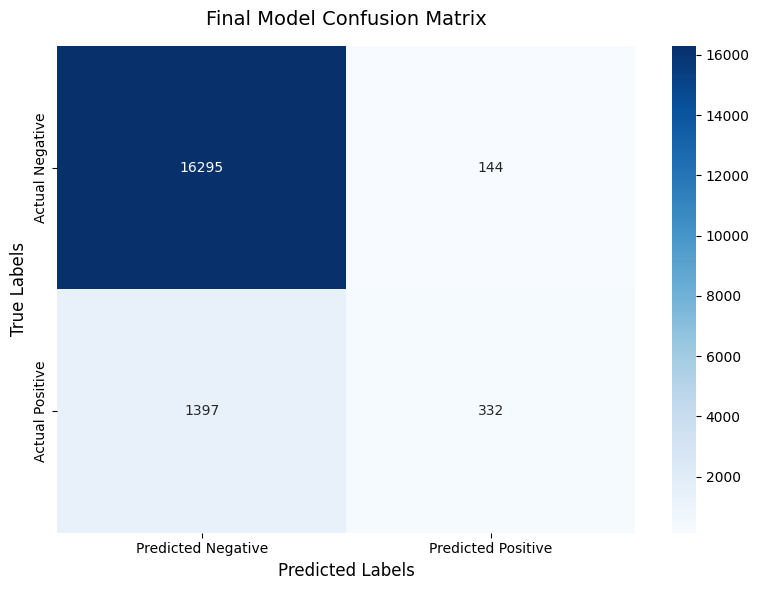


--- ERROR TYPE BREAKDOWN ---
True Negatives (Correctly Identified Non-Hazardous): 16295
False Positives (Type I Error - False Alarms):         144
False Negatives (Type II Error - Missed Targets):     1397
True Positives  (Correctly Identified Hazardous):     332


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# 1. Generate the standard text-based Classification Report
# This breaks down precision, recall, and f1-score per individual class
print("--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, final_test_preds, target_names=['Not Hazardous', 'Hazardous']))

# 2. Compute the Confusion Matrix to look at raw counts
cm = confusion_matrix(y_test, final_test_preds)

# 3. Plot an interactive/clean Confusion Matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)

plt.title('Final Model Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Extract raw counts for business/domain context analysis
tn, fp, fn, tp = cm.ravel()
print("\n--- ERROR TYPE BREAKDOWN ---")
print(f"True Negatives (Correctly Identified Non-Hazardous): {tn}")
print(f"False Positives (Type I Error - False Alarms):         {fp}")
print(f"False Negatives (Type II Error - Missed Targets):     {fn}")
print(f"True Positives  (Correctly Identified Hazardous):     {tp}")

## # STEP 6: MODEL SERIALIZATION (SAVING)

In [76]:
import pickle

# 1. Define the filename for your saved model
model_filename = 'final_neo_classification_model.pkl'

# 2. Save the trained final model to disk
try:
    with open(model_filename, 'wb') as file:
        pickle.dump(final_model, file)
    print(f"🎉 Success! Model successfully serialized and saved as: '{model_filename}'")
except NameError:
    print("❌ Error: 'final_model' variable not found. Make sure you've run your training cell first!")

# ==========================================
# VERIFICATION: TEST LOADING THE MODEL
# ==========================================
print("\nVerifying saved model file...")

# 3. Load the model back into a new variable
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

# 4. Run a quick sanity check prediction to confirm it works
sample_pred = loaded_model.predict(x_test_tran[:5])
print(f"Verification prediction on first 5 test samples: {sample_pred}")
print("Model is fully functional and ready for deployment!")

🎉 Success! Model successfully serialized and saved as: 'final_neo_classification_model.pkl'

Verifying saved model file...
Verification prediction on first 5 test samples: [False False False False False]
Model is fully functional and ready for deployment!


# Sprint 4

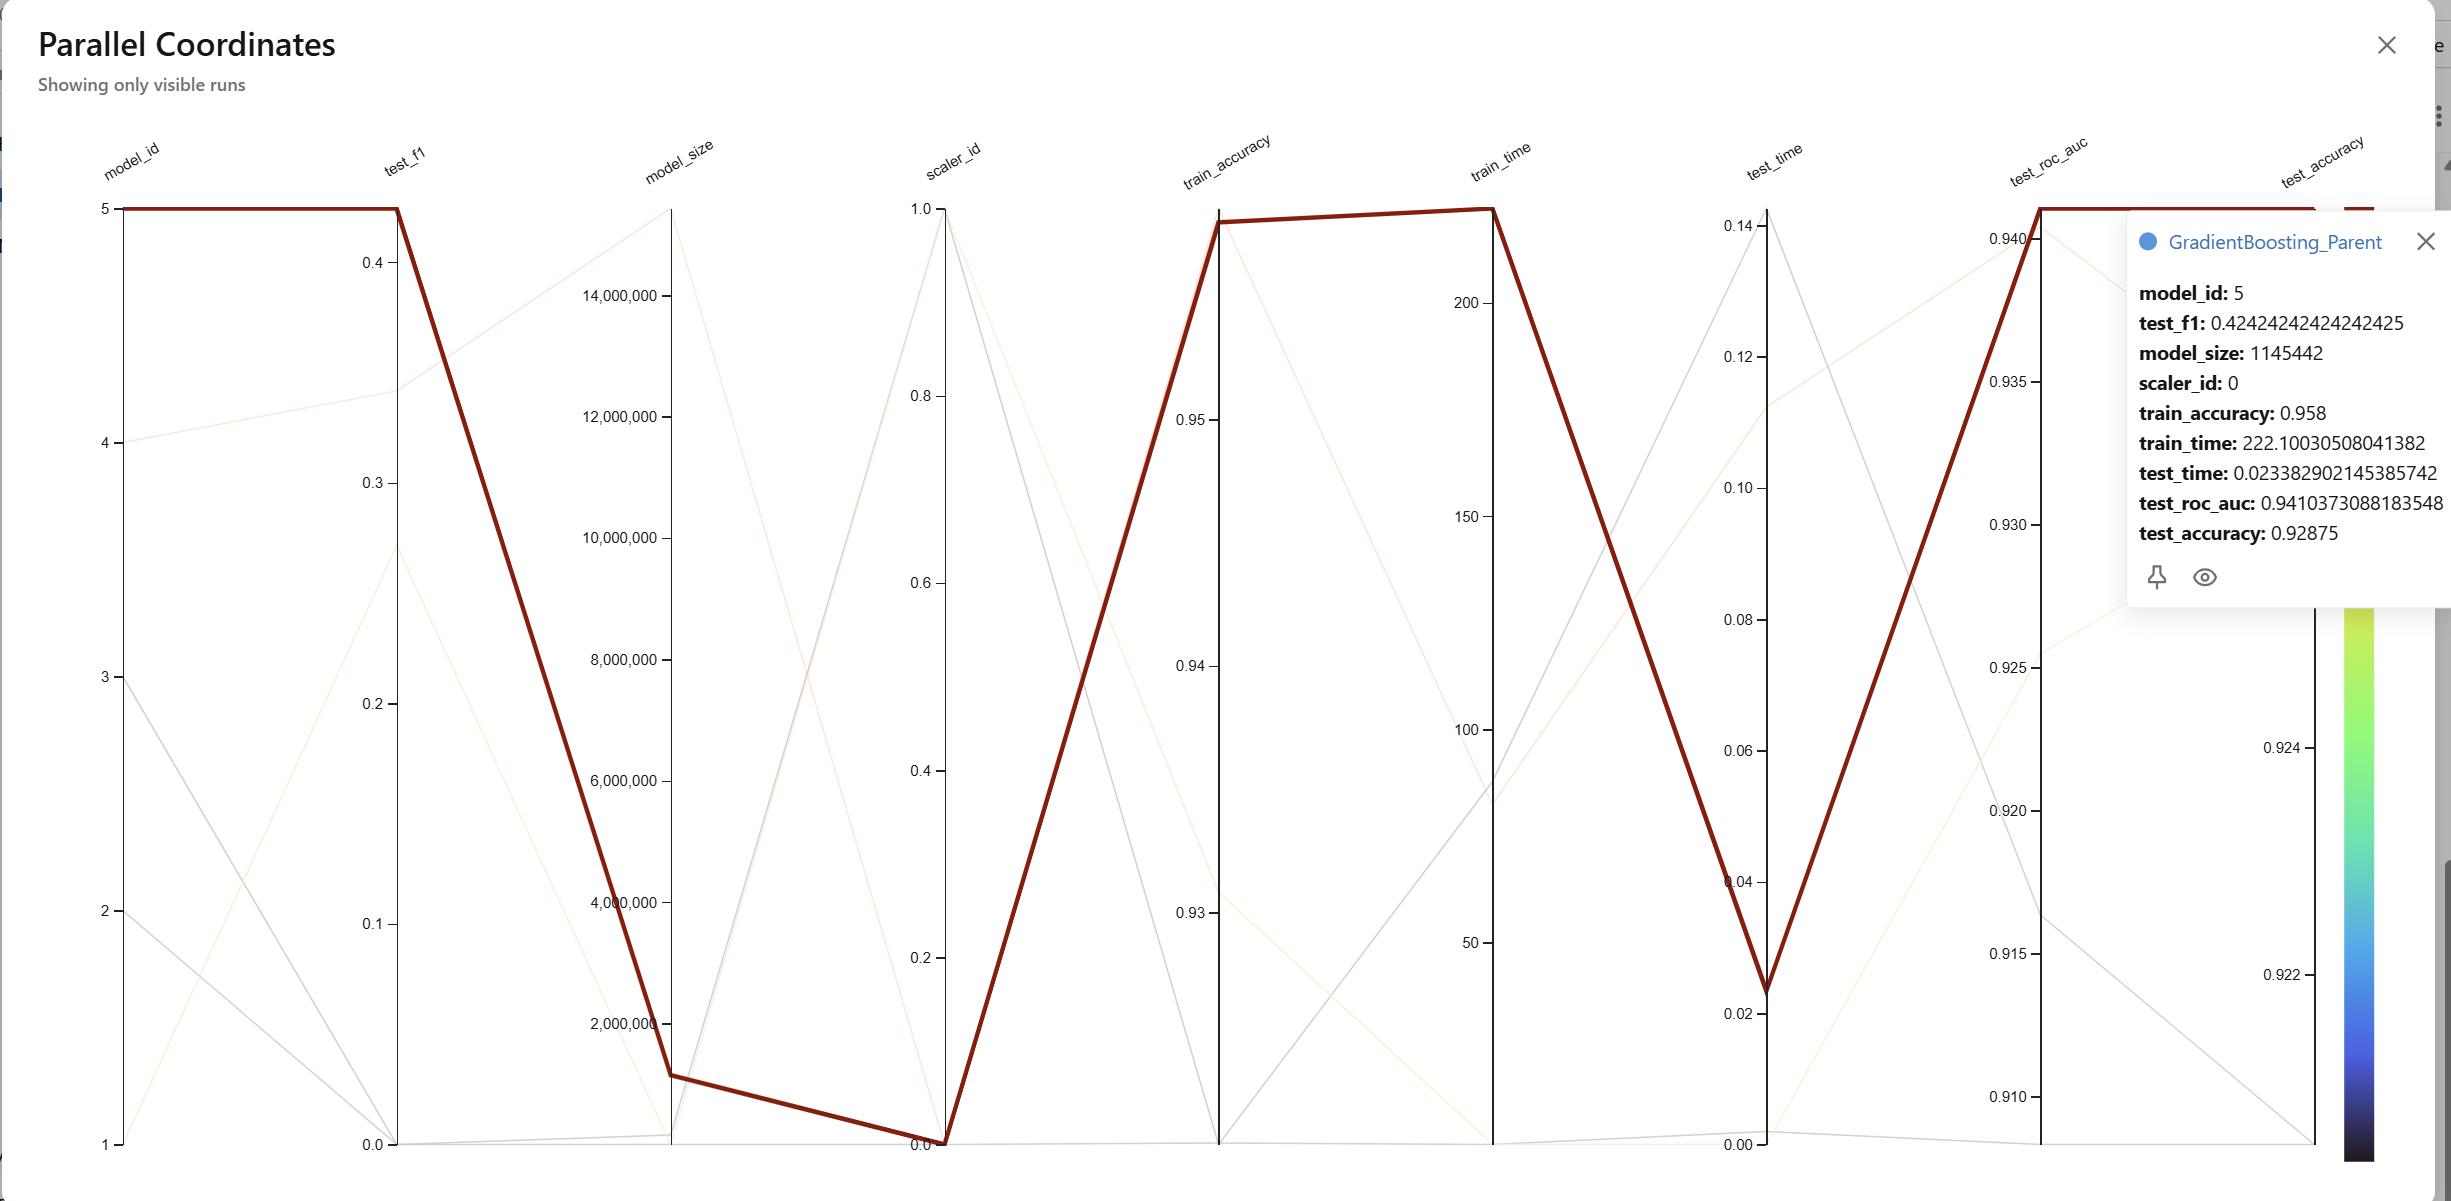

### Exceptional Generalization (High Accuracy & ROC-AUC)
- Train vs. Test Accuracy: The model achieves a train_accuracy of 0.958 (95.8%) and maintains a test_accuracy of 0.92875 (92.88%).

- No Severe Overfitting: The gap between training and testing accuracy is small (~3%). This indicates that the Gradient Boosting algorithm has successfully learned the underlying patterns of the data rather than just memorizing the training set.

- Robust Classification Quality: The test_roc_auc is 0.941 (94.1%). A high ROC-AUC score means the model has excellent discriminative power—it is highly capable of distinguishing between classes regardless of the classification threshold.

### Ultra-Fast Inference Time (test_time)
- The Data: While the model takes a significant amount of time to train (train_time: 222.10 seconds), its test_time is incredibly low at just 0.023 seconds.

- Why it matters: In real-world production environments, training happens offline, so a long training time is often acceptable. However, inference time (how fast the model predicts on new data) is critical. A test time of ~0.02 seconds means this model can be deployed in environments requiring low latency or near-real-time predictions.

### Lightweight Footprint (model_size)
- The Data: Looking at the parallel coordinates chart, the model_size axis goes all the way up to over 14,000,000. This Gradient Boosting model has a model_size of 1,145,442.

### Why it matters: 
- On the chart, you can see the brown line dipping drastically low on the model_size axis. This means that compared to other potential model candidates in your run, this model is highly optimized and memory-efficient. A smaller model size makes it easier to deploy on cloud servers with limited RAM or edge devices.

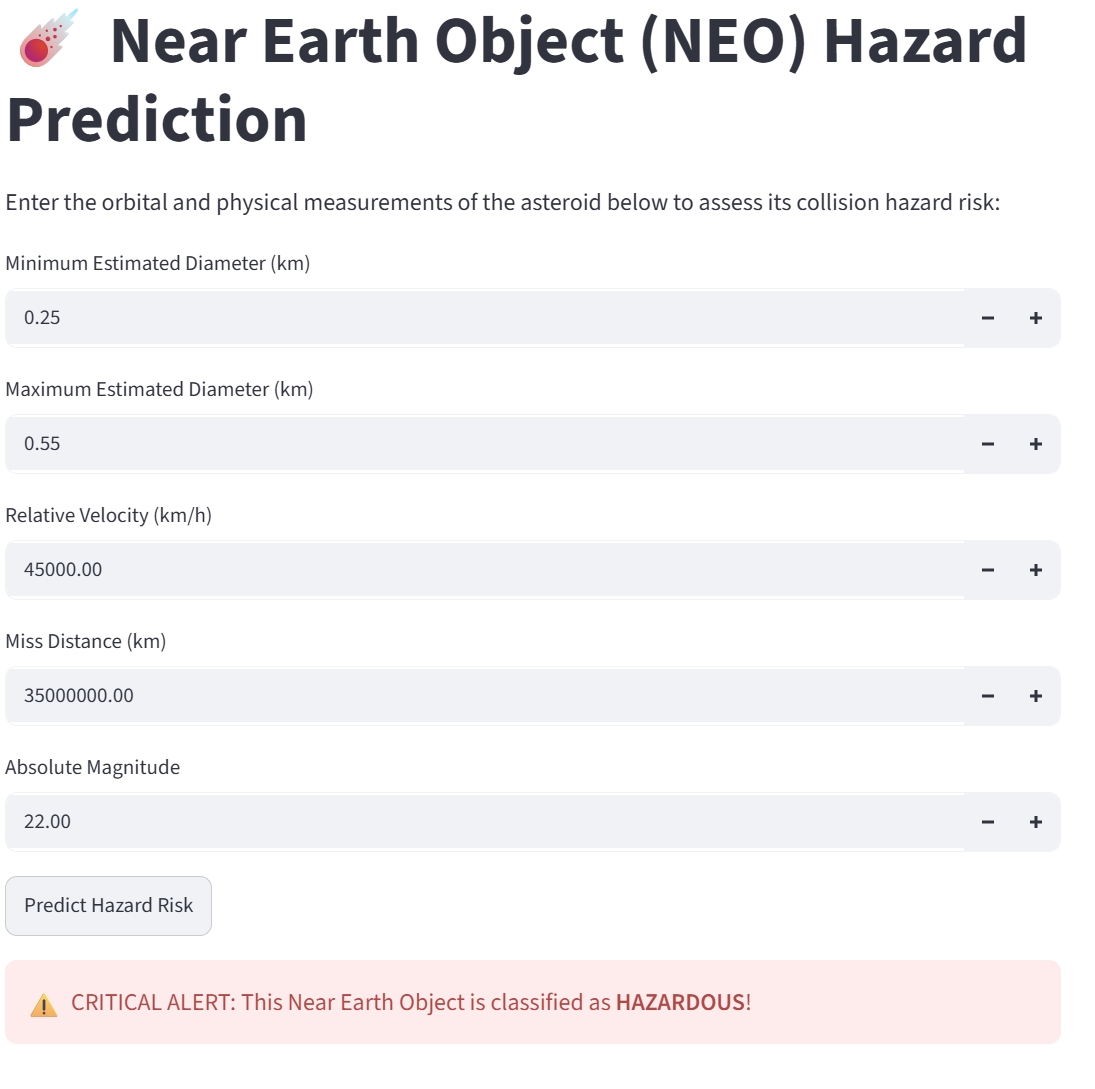

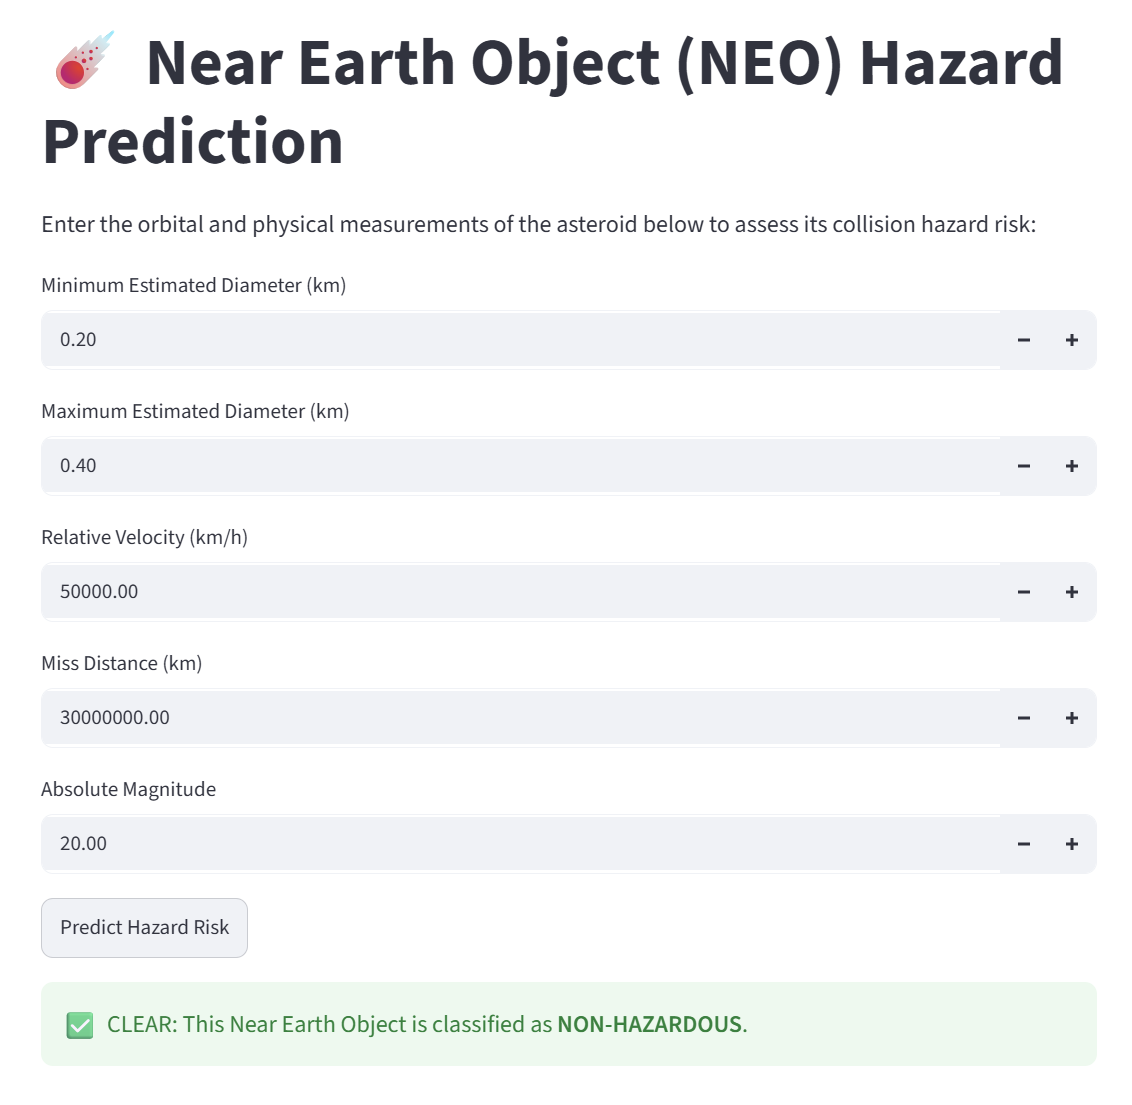